# 02 — Pré-processamento e baseline de persistência

Esta é a próxima fase após a auditoria. O notebook transforma os registros do AZT1D em janelas sem vazamento temporal e mede a baseline de persistência: a previsão para 30 minutos é igual à última glicose observada.

A baseline não treina modelo algum. Ela valida o pipeline e estabelece o patamar mínimo que a futura LSTM populacional deve superar.

## Decisões de pré-processamento v0

- Usar somente os 25 CSVs em CGM Records.
- Remover apenas linhas completamente idênticas; não deduplicar por timestamp.
- Reunir os registros em bins de 5 minutos. Um bin com mais de um valor CGM distinto é ambíguo e não pode gerar janela.
- Não interpolar CGM. Ausência, lacuna ou conflito encerra o segmento.
- Usar CGM, bolus total e carboidratos como configuração multivariada candidata. Basal e modo do dispositivo ficam fora da v0.
- O Subject 23 permanece na baseline CGM-only, mas não é elegível à futura análise multivariada porque não possui carboidrato positivo registrado.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print('matplotlib não está instalado; os relatórios tabulares continuam disponíveis.')

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

def find_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'AZT1D 2025' / 'CGM Records').is_dir() and (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError('Abra este notebook dentro do repositório do projeto.')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.azt1d import (
    FEATURE_COLUMNS,
    build_cgm_windows,
    combine_window_sets,
    compute_persistence_baseline,
    discover_subject_files,
    load_subject,
    make_5min_grid,
    make_subject_split,
    validate_window_set,
)

print(f'Raiz do projeto: {PROJECT_ROOT}')

Raiz do projeto: C:\Users\lucas\OneDrive\Área de Trabalho\Presente\fuckuldade\Projeto-Transformador-2


In [2]:
FREQUENCY = '5min'
HISTORY_STEPS = 12
HORIZON_STEPS = 6
SPLIT_SEED = 42
TRAIN_SIZE = 18
VALIDATION_SIZE = 2
TEST_SIZE = 5
SAVE_REPORTS = True

DATA_DIR = PROJECT_ROOT / 'AZT1D 2025' / 'CGM Records'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'preprocessing_baseline'
CGM_ONLY_FEATURES = ('CGM',)

feature_policy = pd.DataFrame([
    ('CGM', 'usar', 'alvo e histórico da baseline; conflito no bin exclui janela'),
    ('TotalBolusInsulinDelivered', 'candidato', 'somar por bin após deduplicação exata'),
    ('CarbSize', 'candidato', 'somar por bin; Subject 23 não entra no futuro multivariado'),
    ('Basal', 'excluir na v0', 'escala aparentemente mista entre participantes'),
    ('DeviceMode e BolusType', 'excluir na v0', 'valores heterogêneos e sem regra definida'),
], columns=['campo', 'decisão', 'motivo'])

print(f'Entrada: {HISTORY_STEPS} bins de {FREQUENCY}; alvo: +{HORIZON_STEPS} bins.')
feature_policy

Entrada: 12 bins de 5min; alvo: +6 bins.


,campo,decisão,motivo
0,CGM,usar,alvo e histórico da baseline; conflito no bin ...
1,TotalBolusInsulinDelivered,candidato,somar por bin após deduplicação exata
2,CarbSize,candidato,somar por bin; Subject 23 não entra no futuro ...
3,Basal,excluir na v0,escala aparentemente mista entre participantes
4,DeviceMode e BolusType,excluir na v0,valores heterogêneos e sem regra definida


In [3]:
subject_files = discover_subject_files(DATA_DIR)
loaded = {
    subject: load_subject(subject, path)
    for subject, path in subject_files.items()
}
frames = {subject: item[0] for subject, item in loaded.items()}
load_report = pd.DataFrame([item[1] for item in loaded.values()]).sort_values('subject')

assert set(subject_files) == set(range(1, 26))
assert load_report['invalid_timestamps'].eq(0).all()

print(f'Participantes carregados: {len(frames)}')
load_report

Participantes carregados: 25


,subject,source_file,raw_rows,exact_duplicates_removed,invalid_timestamps,used_cgm_alias,numeric_parse_errors
0,1,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,11042,144,0,False,{}
1,2,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,11194,0,0,False,{}
2,3,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,11605,861,0,False,{}
3,4,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,12822,70,0,False,{}
4,5,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,13210,1,0,False,{}
5,6,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,12901,166,0,False,{}
6,7,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,13392,0,0,False,{}
7,8,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,8139,19,0,False,{}
8,9,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,10717,21,0,False,{}
9,10,C:\Users\lucas\OneDrive\Área de Trabalho\Prese...,12183,288,0,False,{}


In [4]:
grids = {
    subject: make_5min_grid(frame, frequency=FREQUENCY)
    for subject, frame in frames.items()
}

grid_rows = []
for subject, grid in grids.items():
    grid_rows.append({
        'subject': subject,
        'grid_bins': len(grid),
        'valid_cgm_bins': int(grid['valid_cgm'].sum()),
        'missing_or_ambiguous_cgm_bins': int((~grid['valid_cgm']).sum()),
        'cgm_conflict_bins': int(grid['cgm_conflict'].sum()),
        'bins_with_multiple_raw_records': int(grid['raw_rows_in_bin'].gt(1).sum()),
        'clean_segments': int(grid['clean_segment_id'].dropna().nunique()),
        'bolus_units_sum': grid['bolus_units'].sum(),
        'carbs_g_sum': grid['carbs_g'].sum(),
        'has_positive_carbs': bool(grid['carbs_g'].gt(0).any()),
    })

grid_summary = pd.DataFrame(grid_rows).sort_values('subject').reset_index(drop=True)
assert grid_summary['cgm_conflict_bins'].sum() > 0
grid_summary

,subject,grid_bins,valid_cgm_bins,missing_or_ambiguous_cgm_bins,cgm_conflict_bins,bins_with_multiple_raw_records,clean_segments,bolus_units_sum,carbs_g_sum,has_positive_carbs
0,1,11231,10877,354,4,15,36,"5,175.580","7,257.000",True
1,2,11232,11118,114,2,74,9,629.310,"5,747.000",True
2,3,11232,10480,752,116,145,72,"2,719.780","5,762.000",True
3,4,12891,12750,141,0,2,8,395.410,"2,595.000",True
4,5,13248,12807,441,100,229,185,"1,203.500","6,302.000",True
5,6,12839,12730,109,0,5,7,558.630,"4,848.000",True
6,7,13536,13347,189,1,44,17,714.250,"7,755.000",True
7,8,8065,7919,146,84,86,87,308.230,"2,525.000",True
8,9,11232,10674,558,0,15,27,767.530,"4,656.000",True
9,10,12096,11881,215,0,12,20,436.480,"1,715.000",True


## Geração de janelas

Com 12 entradas e horizonte de 6 bins, uma janela válida usa os bins i até i+11 como entrada e CGM no bin i+17 como alvo. Portanto, exige 18 bins CGM consecutivos e sem conflito.

O timestamp do bin representa a faixa de 5 minutos iniciada naquele horário; todos os eventos do bin de entrada ocorrem antes da observação representativa ao final daquela faixa.

In [5]:
cgm_windows_by_subject = {
    subject: build_cgm_windows(
        grid, subject, HISTORY_STEPS, HORIZON_STEPS, CGM_ONLY_FEATURES
    )
    for subject, grid in grids.items()
}
multivariate_subjects = grid_summary.loc[grid_summary['has_positive_carbs'], 'subject'].tolist()
multivariate_windows_by_subject = {
    subject: build_cgm_windows(
        grids[subject], subject, HISTORY_STEPS, HORIZON_STEPS, FEATURE_COLUMNS
    )
    for subject in multivariate_subjects
}

all_cgm_windows = combine_window_sets(list(cgm_windows_by_subject.values()))
all_multivariate_windows = combine_window_sets(list(multivariate_windows_by_subject.values()))
cgm_window_checks = validate_window_set(
    all_cgm_windows, HISTORY_STEPS, HORIZON_STEPS, FREQUENCY
)
multivariate_window_checks = validate_window_set(
    all_multivariate_windows, HISTORY_STEPS, HORIZON_STEPS, FREQUENCY
)
assert cgm_window_checks['passed'].all()
assert multivariate_window_checks['passed'].all()

window_summary = pd.DataFrame([
    {
        'subject': subject,
        'cgm_only_windows': window_set.size,
        'multivariate_eligible': subject in multivariate_windows_by_subject,
        'multivariate_windows': multivariate_windows_by_subject[subject].size
            if subject in multivariate_windows_by_subject else 0,
    }
    for subject, window_set in cgm_windows_by_subject.items()
]).sort_values('subject').reset_index(drop=True)

print(f'Janelas CGM-only: {all_cgm_windows.size}')
print(f'Janelas multivariadas candidatas: {all_multivariate_windows.size}')
print(f'Participantes multivariados elegíveis: {multivariate_subjects}')
window_summary

Janelas CGM-only: 286690
Janelas multivariadas candidatas: 273373
Participantes multivariados elegíveis: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25]


,subject,cgm_only_windows,multivariate_eligible,multivariate_windows
0,1,10399,True,10399
1,2,10965,True,10965
2,3,9686,True,9686
3,4,12629,True,12629
4,5,11091,True,11091
5,6,12611,True,12611
6,7,13104,True,13104
7,8,6824,True,6824
8,9,10367,True,10367
9,10,11650,True,11650


In [6]:
subject_split = make_subject_split(
    list(subject_files),
    train_size=TRAIN_SIZE,
    validation_size=VALIDATION_SIZE,
    test_size=TEST_SIZE,
    seed=SPLIT_SEED,
)
train_subjects = set(subject_split.loc[subject_split['role'].eq('train'), 'subject'])
validation_subjects = set(subject_split.loc[subject_split['role'].eq('validation'), 'subject'])
test_subjects = set(subject_split.loc[subject_split['role'].eq('test'), 'subject'])

assert not (train_subjects & validation_subjects)
assert not (train_subjects & test_subjects)
assert not (validation_subjects & test_subjects)
assert train_subjects | validation_subjects | test_subjects == set(subject_files)

test_cgm_windows = combine_window_sets([
    cgm_windows_by_subject[subject] for subject in sorted(test_subjects)
])
test_window_checks = validate_window_set(
    test_cgm_windows, HISTORY_STEPS, HORIZON_STEPS, FREQUENCY
)
assert test_window_checks['passed'].all()

print(f'Treino: {sorted(train_subjects)}')
print(f'Validação: {sorted(validation_subjects)}')
print(f'Teste externo: {sorted(test_subjects)}')
subject_split

Treino: [1, 4, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 25]
Validação: [3, 24]
Teste externo: [2, 5, 9, 14, 23]


,subject,role
0,1,train
1,2,test
2,3,validation
3,4,train
4,5,test
5,6,train
6,7,train
7,8,train
8,9,test
9,10,train


In [7]:
# Resultado primário: somente participantes nunca usados em treino ou validação futuros.
test_predictions, test_metrics = compute_persistence_baseline(test_cgm_windows)

# Diagnóstico secundário: todos os participantes, sem usar este resultado para escolher modelo.
all_predictions, all_metrics_diagnostic = compute_persistence_baseline(all_cgm_windows)

test_subject_metrics = test_metrics.loc[
    test_metrics['subject'].isin(sorted(test_subjects))
].copy()
print('Baseline de persistência no teste externo, em mg/dL:')
test_metrics

Baseline de persistência no teste externo, em mg/dL:


,subject,windows,mae,rmse
0,2,10965,19.919,27.683
1,5,11091,16.524,21.776
2,9,10367,19.567,26.351
3,14,12586,14.889,20.348
4,23,13317,17.784,24.154
5,overall_pooled,58326,17.638,24.088
6,overall_macro,5,17.737,24.062


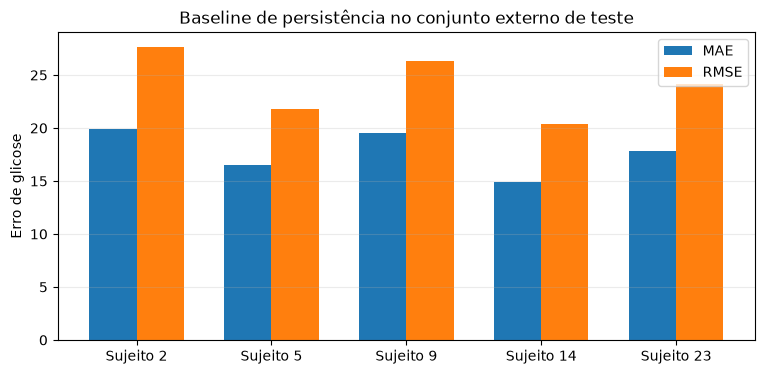

In [8]:
if HAS_MATPLOTLIB:
    plotted = test_subject_metrics.sort_values('subject')
    positions = np.arange(len(plotted))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(positions - width / 2, plotted['mae'], width, label='MAE')
    ax.bar(positions + width / 2, plotted['rmse'], width, label='RMSE')
    ax.set_xticks(positions, [f'Sujeito {subject}' for subject in plotted['subject']])
    ax.set_ylabel('Erro de glicose')
    ax.set_title('Baseline de persistência no conjunto externo de teste')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    plt.show()
else:
    print('Instale matplotlib para gerar o gráfico de métricas.')

In [9]:
if SAVE_REPORTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    load_report.to_csv(OUTPUT_DIR / 'load_report.csv', index=False)
    grid_summary.to_csv(OUTPUT_DIR / 'clean_grid_summary.csv', index=False)
    window_summary.to_csv(OUTPUT_DIR / 'window_summary.csv', index=False)
    cgm_window_checks.to_csv(OUTPUT_DIR / 'cgm_window_checks.csv', index=False)
    multivariate_window_checks.to_csv(OUTPUT_DIR / 'multivariate_window_checks.csv', index=False)
    subject_split.to_csv(OUTPUT_DIR / 'subject_split_v0.csv', index=False)
    feature_policy.to_csv(OUTPUT_DIR / 'feature_policy_v0.csv', index=False)
    test_predictions.to_csv(OUTPUT_DIR / 'persistence_test_predictions.csv', index=False)
    test_metrics.to_csv(OUTPUT_DIR / 'persistence_test_metrics.csv', index=False)
    all_metrics_diagnostic.to_csv(OUTPUT_DIR / 'persistence_all_subjects_diagnostic.csv', index=False)
    print(f'Relatórios salvos em: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')

print('Fase 2 concluída: a próxima etapa é treinar uma LSTM apenas nos sujeitos de treino,')
print('ajustar normalização exclusivamente no treino e usar a validação para escolher parâmetros.')

Relatórios salvos em: results\preprocessing_baseline
Fase 2 concluída: a próxima etapa é treinar uma LSTM apenas nos sujeitos de treino,
ajustar normalização exclusivamente no treino e usar a validação para escolher parâmetros.


## Próxima fase

Treinar uma LSTM populacional pequena com os participantes de treino, mantendo validação e teste externo isolados. A normalização deverá ser ajustada apenas no treino. A comparação principal será LSTM populacional versus esta baseline de persistência; transfer learning só vem depois dessa comparação estar estável.